In [1]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.9 MB 3.7 MB/s eta 0:00:03
   --------- ------------------------------ 2.1/8.9 MB 4.9 MB/s eta 0:00:02
   --------------- ------------------------ 3.4/8.9 MB 5.9 MB/s eta 0:00:01
   ---------------------- ----------------- 5.0/8.9 MB 6.3 MB/s eta 0:00:01
   ---------------------- ----------------- 5.0/8.9 MB 6.3 MB/s eta 0:00:01
   ------------------------ --------------- 5.5/8.9 MB 4.5 MB/s eta 0:00:01
   --------------------------- ------------ 6.0/8.9 MB 4.3 MB/s eta 0:00:01
   ----------------------------- ---------- 6.6/8.9 MB 4.1 MB/s eta 0:00:01
   ------------------------------- -------- 7.1/8.9 MB 3.7 MB/s eta 0:00:01
   ---------------------------------- ----- 7.6/8.9 MB 3.6 MB/s eta 0:00:01
   ------------------------------------ --- 8.1/8.9 MB 3.5 MB/s eta 0:00:01
   -----------------------

In [3]:
!pip install numpy pandas matplotlib seaborn scikit-learn

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/11.3 MB 7.5 MB/s eta 0:00:02
   --------- ------------------------------ 2.6/11.3 MB 6.9 MB/s eta 0:00:02
   ------------- -------------------------- 3.9/11.3 MB 6.2 MB/s eta 0:00:02
   ------------------ --------------------- 5.2/11.3 MB 6.5 MB/s eta 0:00:01
   ----------------------- ---------------- 6.6/11.3 MB 6.4 MB/s eta 0:00:01
   --------------------------- ------------ 7.9/11.3 MB 6.2 MB/s eta 0:00:01
   -------------------------------- ------- 9.2/11.3 MB 6.3 MB/s eta 0:00:01
   ------------------------------------ --- 10.5/11.3 MB 6.3 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 6.2 MB/s  0:00:01
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.1 MB 7.4 MB/s eta 0:00:01
   -------------- ------------------------- 2.9/8.1 MB 7.0 MB/s eta 0:00:01
   --------------

In [4]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV  # Hyperparameyer tuning

from sklearn.preprocessing import MinMaxScaler, StandardScaler  #Feature Scaling

from sklearn.neighbors import KNeighborsClassifier

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [7]:
df = pd.read_csv(r"C:\Users\sahil_exgi\Downloads\heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [9]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Minmax Scaler

In [12]:
age_63 = (63-29)/(77-29)
age_63


0.7083333333333334

In [14]:
X = df.drop('target', axis=1)
y = df['target']

### Minmax Scalar (Normalization)

In [15]:
# Create instance of MInMax Scaler (Normalization)
minmax_scaler = MinMaxScaler()
X_scaled = minmax_scaler.fit_transform(X)
X_scaled
X_minmax_df = pd.DataFrame(X_scaled, columns=X.columns)
X_minmax_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.708333,1.0,1.000000,0.481132,0.244292,1.0,0.0,0.603053,0.0,0.370968,0.0,0.00,0.333333
1,0.166667,1.0,0.666667,0.339623,0.283105,0.0,0.5,0.885496,0.0,0.564516,0.0,0.00,0.666667
2,0.250000,0.0,0.333333,0.339623,0.178082,0.0,0.0,0.770992,0.0,0.225806,1.0,0.00,0.666667
3,0.562500,1.0,0.333333,0.245283,0.251142,0.0,0.5,0.816794,0.0,0.129032,1.0,0.00,0.666667
4,0.583333,0.0,0.000000,0.245283,0.520548,0.0,0.5,0.702290,1.0,0.096774,1.0,0.00,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,0.583333,0.0,0.000000,0.433962,0.262557,0.0,0.5,0.396947,1.0,0.032258,0.5,0.00,1.000000
299,0.333333,1.0,1.000000,0.150943,0.315068,0.0,0.5,0.465649,0.0,0.193548,0.5,0.00,1.000000
300,0.812500,1.0,0.000000,0.471698,0.152968,1.0,0.5,0.534351,0.0,0.548387,0.5,0.50,1.000000
301,0.583333,1.0,0.000000,0.339623,0.011416,0.0,0.5,0.335878,1.0,0.193548,0.5,0.25,1.000000


### Train Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_minmax_df, y, 
                                            test_size=0.20, random_state=42)

In [18]:
X_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,0.270833,1.0,0.333333,0.245283,0.385845,0.0,0.5,0.694656,0.0,0.000000,1.0,0.00,0.666667
202,0.604167,1.0,0.000000,0.528302,0.328767,0.0,0.0,0.305344,1.0,0.129032,1.0,0.00,1.000000
196,0.354167,1.0,0.666667,0.528302,0.239726,0.0,0.5,0.580153,0.0,0.580645,0.5,0.00,0.666667
75,0.541667,0.0,0.333333,0.386792,0.283105,0.0,0.0,0.687023,0.0,0.225806,0.5,0.00,0.666667
176,0.645833,1.0,0.000000,0.216981,0.237443,1.0,0.5,0.679389,1.0,0.225806,1.0,0.50,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,0.437500,1.0,0.666667,0.433962,0.244292,0.0,0.5,0.702290,0.0,0.096774,0.5,0.25,1.000000
71,0.458333,1.0,0.666667,0.000000,0.230594,0.0,0.5,0.633588,1.0,0.000000,1.0,0.25,1.000000
106,0.833333,1.0,1.000000,0.622642,0.246575,1.0,0.0,0.458015,0.0,0.016129,0.5,0.25,0.666667
270,0.354167,1.0,0.000000,0.245283,0.280822,0.0,0.0,0.557252,0.0,0.129032,1.0,0.00,1.000000


In [19]:
X_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
179,0.583333,1.0,0.000000,0.528302,0.342466,0.0,0.0,0.312977,1.0,0.096774,0.5,0.25,0.333333
228,0.625000,1.0,1.000000,0.716981,0.369863,0.0,0.0,0.671756,0.0,0.032258,0.5,0.00,1.000000
111,0.583333,1.0,0.666667,0.528302,0.000000,1.0,0.5,0.778626,0.0,0.032258,1.0,0.25,1.000000
246,0.562500,0.0,0.000000,0.377358,0.646119,0.0,0.0,0.603053,1.0,0.306452,0.5,0.50,1.000000
60,0.875000,0.0,0.666667,0.150943,0.317352,1.0,0.0,0.450382,0.0,0.000000,1.0,0.25,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,0.833333,1.0,0.666667,0.433962,0.292237,0.0,0.0,0.572519,0.0,0.322581,0.5,0.75,1.000000
104,0.437500,1.0,0.666667,0.330189,0.159817,0.0,0.5,0.702290,0.0,0.000000,1.0,0.00,0.666667
300,0.812500,1.0,0.000000,0.471698,0.152968,1.0,0.5,0.534351,0.0,0.548387,0.5,0.50,1.000000
193,0.645833,1.0,0.000000,0.481132,0.356164,0.0,0.0,0.541985,1.0,0.451613,0.5,0.50,1.000000


### Train Model

In [20]:
knn_class = KNeighborsClassifier(n_neighbors=11, p=2)
knn_class.fit(X_train, y_train)

,n_neighbors,11
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [21]:
y_pred = knn_class.predict(X_test)
y_pred

array([0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [22]:
y_test[:5]

179    0
228    0
111    1
246    0
60     1
Name: target, dtype: int64

In [23]:
y_pred[:5]

array([0, 0, 1, 0, 1])

### Evaluation

In [24]:
con_matrix = confusion_matrix(y_test, y_pred)
con_matrix

array([[26,  3],
       [ 8, 24]])

In [25]:
accuracy= accuracy_score(y_test, y_pred)
accuracy

0.819672131147541

In [26]:
# Classification Report
class_report = classification_report(y_test, y_pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.76      0.90      0.83        29
           1       0.89      0.75      0.81        32

    accuracy                           0.82        61
   macro avg       0.83      0.82      0.82        61
weighted avg       0.83      0.82      0.82        61



### Hyperparameter Tuning

### Grid SearchCV

In [27]:
k = np.arange(2,15)
k

array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [28]:
k = np.arange(2,50)
p = [1,2]
hyp = {'n_neighbors': k, "p":p}


In [29]:

knn = KNeighborsClassifier()
gscv_knn_model = GridSearchCV(knn,hyp,cv=5)
gscv_knn_model.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': array([ 2, 3..., 47, 48, 49]), 'p': [1, 2]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,np.int64(5)


In [30]:
gscv_knn_model.best_estimator_

,n_neighbors,np.int64(5)
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [31]:
gscv_knn_model.best_params_

{'n_neighbors': np.int64(5), 'p': 1}

In [33]:
knn_class_gs = KNeighborsClassifier(n_neighbors=5, p=1)
knn_class_gs.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [34]:
y_pred_gs = knn_class_gs.predict(X_test)
y_pred_gs


array([0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [35]:
accuracy_gs= accuracy_score(y_test, y_pred_gs)
accuracy_gs

0.819672131147541

In [36]:
knn_class_rs = KNeighborsClassifier(n_neighbors=48, p=1)
knn_class_rs.fit(X_train, y_train)

,n_neighbors,48
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [37]:
y_pred_rs = knn_class_rs.predict(X_test)
y_pred_rs

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [38]:
accuracy_rs= accuracy_score(y_test, y_pred_rs)
accuracy_rs

0.8852459016393442

In [39]:
from sklearn.metrics import roc_auc_score, roc_curve

In [40]:
roc_auc_score(y_test, y_pred)

0.8232758620689656

In [41]:
roc_auc_score(y_test , y_pred_rs)


0.8841594827586207

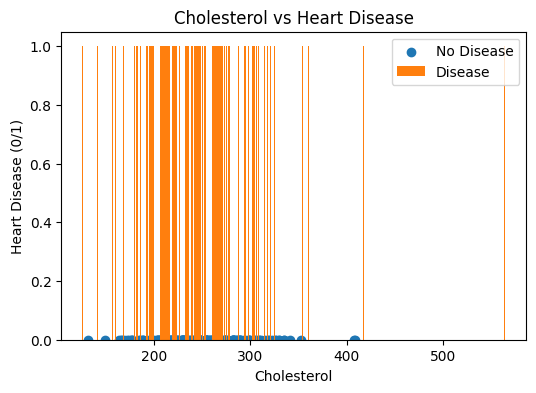

In [43]:
plt.figure(figsize=(6,4))

# No disease
plt.scatter(df[df["target"]==0]["chol"],
            df[df["target"]==0]["target"],
            label="No Disease")

# Disease
plt.bar(df[df["target"]==1]["chol"],
            df[df["target"]==1]["target"],
            label="Disease")

plt.xlabel("Cholesterol")
plt.ylabel("Heart Disease (0/1)")
plt.title("Cholesterol vs Heart Disease")

plt.legend()
plt.show()

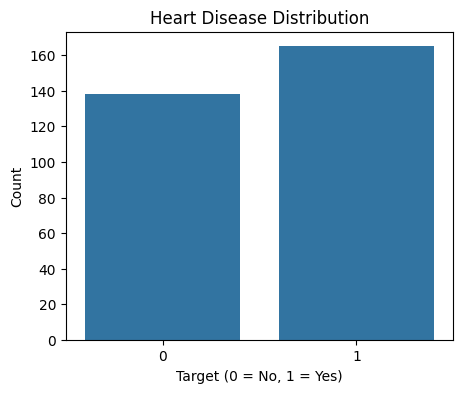

In [44]:
plt.figure(figsize=(5,4))

sns.countplot(x="target", data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Target (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

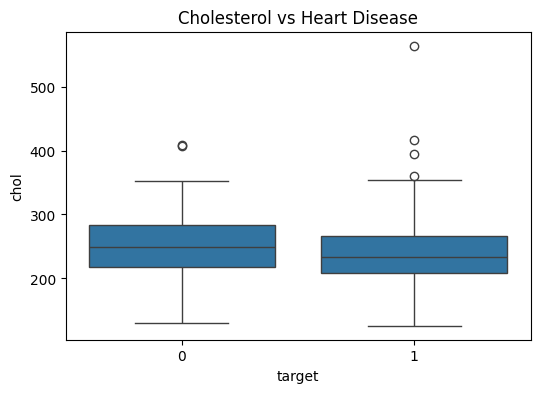

In [45]:
plt.figure(figsize=(6,4))

sns.boxplot(x="target", y="chol", data=df)

plt.title("Cholesterol vs Heart Disease")
plt.show()

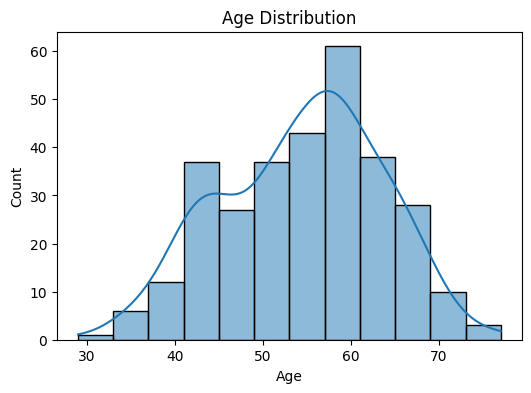

In [46]:
plt.figure(figsize=(6,4))

sns.histplot(df["age"], kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")

plt.show()

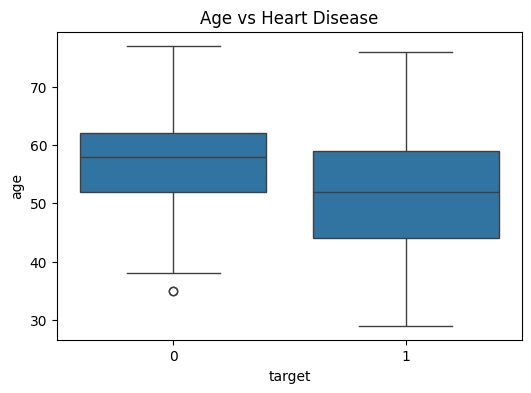

In [47]:
plt.figure(figsize=(6,4))

sns.boxplot(x="target", y="age", data=df)

plt.title("Age vs Heart Disease")

plt.show()

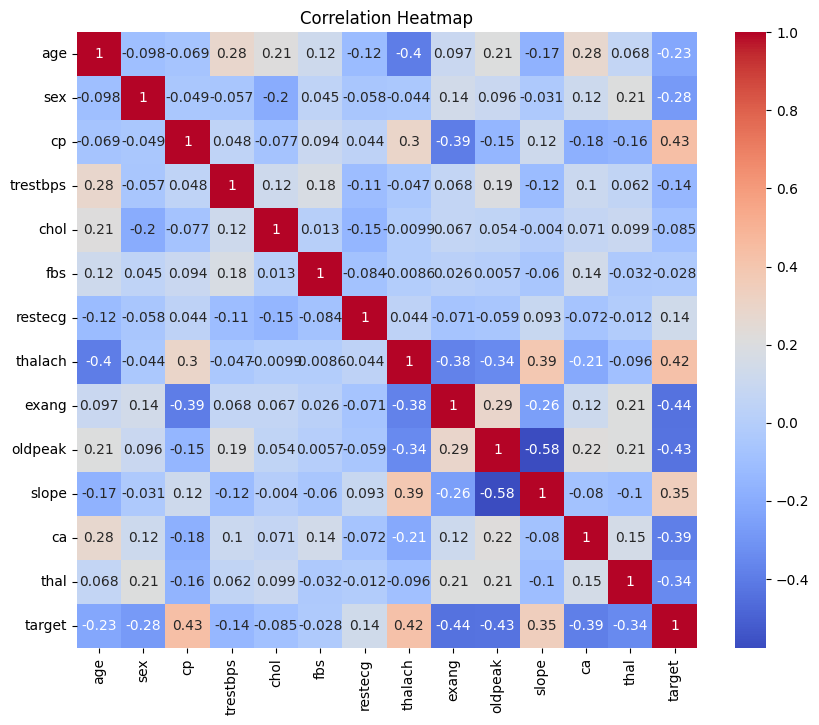

In [48]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

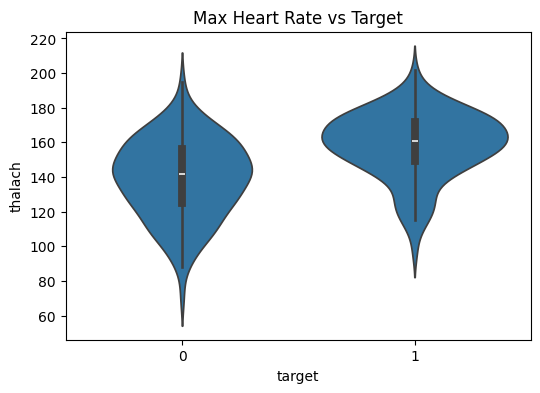

In [56]:
plt.figure(figsize=(6,4))

sns.violinplot(x="target", y="thalach", data=df)

plt.title("Max Heart Rate vs Target")

plt.show()

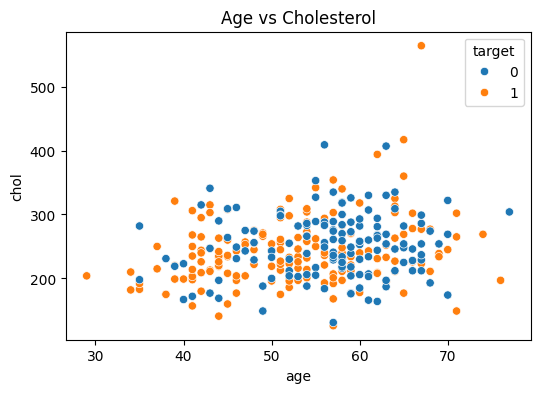

In [50]:
plt.figure(figsize=(6,4))

sns.scatterplot(x="age", y="chol", hue="target", data=df)

plt.title("Age vs Cholesterol")

plt.show()

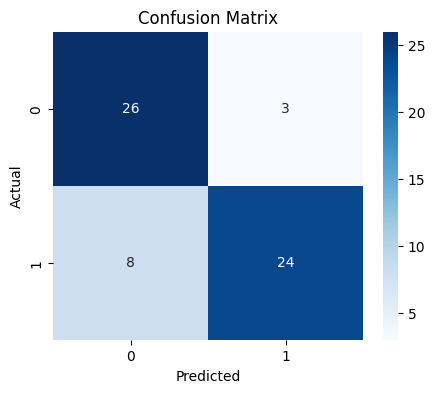

In [51]:
plt.figure(figsize=(5,4))

sns.heatmap(con_matrix, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

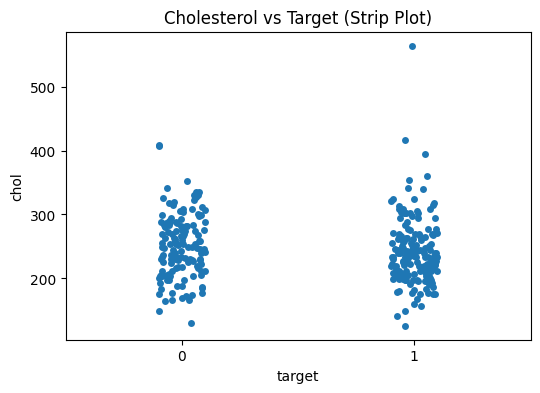

In [57]:
plt.figure(figsize=(6,4))

sns.stripplot(x="target", y="chol", data=df, jitter=True)

plt.title("Cholesterol vs Target (Strip Plot)")
plt.show()